# Project 1 — Founder–Investor Network Analysis in the Indian Startup Ecosystem

### Core Research Question:
> **How are founders and investors connected in the Indian startup ecosystem, and is network position associated with subsequent funding outcomes?**

---

### Project Objectives & Methodology:
1. **Tripartite Network Architecture**: Construct a heterogeneous, multi-entity network ($Founder \rightarrow Startup \leftarrow Investor$) capturing the real-world linkages of the Indian venture landscape.
2. **Multi-Metric Centrality Analysis**: Measure **Degree**, **Betweenness**, **Eigenvector**, and **PageRank** centrality for all key market participants.
3. **Co-Investment Syndicates & Community Detection**: Project bipartite ties into an investor syndicate network and uncover market cliques via modularity maximization.
4. **Network Concentration & Inequality**: Quantify structural capital concentration using the **Lorenz Curve**, **Gini Coefficient**, and the **Herfindahl-Hirschman Index (HHI)**.
5. **Geographic & Sector Heterogeneity**: Investigate geographic differences across primary tech hubs (Bengaluru, Delhi NCR, Mumbai) and vertical specializations.
6. **Econometric Regression Modeling**: Estimate log-linear OLS specifications with heteroskedasticity-robust standard errors (HC1) to test whether network prestige directly predicts capital raised.
7. **Interactive Network Visualization**: Export a standalone, physics-simulated interactive graph using **PyVis**.


## 1. Environment Setup & Dependency Initialization

In [1]:
# Core analytical libraries
import os
import re
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import networkx as nx
import networkx.algorithms.community as nx_comm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pyvis.network import Network
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting defaults
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
sns.set_palette("tab10")

print("All scientific computing and network libraries successfully loaded.")


All scientific computing and network libraries successfully loaded.


## 2. Real-World Data Ingestion & Preprocessing

We ingest the verified `Indian_Startup.csv` dataset, standardizing currency values, parsing multi-entity lists, and mapping cities and sectors into canonical groupings.


In [2]:
# Locate dataset across local workspace and Google Colab environments
possible_paths = [
    'Indian_Startup.csv',
    '/home/niyaz/Documents/MTP/Indian_Startup.csv',
    '/content/startup_data/Indian Startup.csv',
    '/content/Indian Startup.csv'
]

csv_file = next((p for p in possible_paths if os.path.exists(p)), None)
if csv_file is None:
    raise FileNotFoundError("Indian_Startup.csv not found in working paths.")

df_raw = pd.read_csv(csv_file)
print(f"Loaded raw dataset with {df_raw.shape[0]} funding records and {df_raw.shape[1]} attributes.\n")

# --- 1. Clean Funding Amounts to USD Millions ---
def clean_amount_to_usd_mn(val):
    if pd.isna(val) or not isinstance(val, str):
        return np.nan
    val = val.replace(',', '').strip()
    if 'undisclosed' in val.lower():
        return np.nan
    match = re.search(r'\d+\.?\d*', val)
    if not match:
        return np.nan
    num = float(match.group())
    if '₹' in val or 'Rs' in val or 'INR' in val:
        return round((num / 83.0) / 1e6, 3)
    if num > 1e10:  # Erroneous non-delimited rupee entries
        num = num / 83.0
    return round(num / 1e6, 3)

df = df_raw.copy()
df['amount_usd_mn'] = df['Amount'].apply(clean_amount_to_usd_mn)
df['log_amount'] = np.log(df['amount_usd_mn'].replace(0, np.nan))

# --- 2. Entity Parsing for Founders and Investors ---
def parse_entity_list(cell):
    if pd.isna(cell) or not str(cell).strip():
        return []
    text = str(cell).strip().strip('"\'')
    parts = re.split(r'[,;&]|\band\b', text)
    cleaned = []
    for p in parts:
        p_clean = re.sub(r'#REF!|\"|\'', '', p).strip()
        if p_clean and len(p_clean) > 1 and p_clean.lower() not in ['undisclosed', 'nan', 'none', 'and']:
            cleaned.append(p_clean)
    return cleaned

df['founders'] = df['Founder/s'].apply(parse_entity_list)
df['investors'] = df['Investor/s'].apply(parse_entity_list)
df['founder_count'] = df['founders'].apply(len)
df['investor_count'] = df['investors'].apply(len)

# --- 3. Canonical Hub & Sector Categorization ---
def categorize_hub(city):
    if pd.isna(city): return 'Other'
    c_l = str(city).lower()
    if any(k in c_l for k in ['bangalore', 'bengaluru']): return 'Bengaluru'
    if any(k in c_l for k in ['delhi', 'gurugram', 'gurgaon', 'noida', 'faridabad', 'ghaziabad']): return 'Delhi NCR'
    if any(k in c_l for k in ['mumbai', 'thane', 'navi mumbai']): return 'Mumbai'
    if 'hyderabad' in c_l: return 'Hyderabad'
    if 'pune' in c_l: return 'Pune'
    if 'chennai' in c_l: return 'Chennai'
    if any(k in c_l for k in ['ahmedabad', 'ahmadabad']): return 'Ahmedabad'
    if 'jaipur' in c_l: return 'Jaipur'
    if 'kolkata' in c_l: return 'Kolkata'
    return 'Other'

def categorize_sector(s):
    if pd.isna(s): return 'Other'
    s_l = str(s).lower()
    if any(k in s_l for k in ['fintech', 'finance', 'banking', 'capital markets', 'crypto', 'nft', 'blockchain']):
        return 'FinTech & Banking'
    if any(k in s_l for k in ['edtech', 'education', 'e-learning']):
        return 'EdTech & Training'
    if any(k in s_l for k in ['health', 'hospital', 'wellness', 'fitness', 'medical', 'pharma', 'biotech', 'femtech']):
        return 'Healthcare & HealthTech'
    if any(k in s_l for k in ['e-commerce', 'ecommerce', 'd2c', 'retail', 'marketplace', 'social commerce']):
        return 'E-Commerce & D2C'
    if any(k in s_l for k in ['saas', 'software', 'it', 'tech startup', 'ai', 'deeptech', 'cloud', 'cyber']):
        return 'IT, SaaS & AI'
    if any(k in s_l for k in ['logistics', 'supply chain', 'transportation', 'mobility', 'automotive', 'ev']):
        return 'Logistics & Mobility'
    if any(k in s_l for k in ['food', 'beverage', 'kitchen', 'restaurant']):
        return 'Food & Beverages'
    if any(k in s_l for k in ['gaming', 'esports', 'sports', 'entertainment', 'media', 'social media', 'audio']):
        return 'Media & Gaming'
    if any(k in s_l for k in ['agritech', 'farming', 'agriculture']):
        return 'AgriTech'
    if any(k in s_l for k in ['consumer goods', 'fashion', 'apparel', 'furniture', 'lifestyle']):
        return 'Consumer Goods & Lifestyle'
    return 'Other'

def clean_stage(st):
    if pd.isna(st): return 'Undisclosed'
    st_l = str(st).strip().lower()
    if any(k in st_l for k in ['pre-seed', 'seed', 'angel']): return 'Early (Seed/Pre-Seed)'
    if any(k in st_l for k in ['pre-series a', 'series a', 'series a1', 'series a2']): return 'Series A'
    if any(k in st_l for k in ['pre-series b', 'series b', 'series b3']): return 'Series B'
    if any(k in st_l for k in ['series c', 'series d', 'series e', 'series f', 'series g', 'series h', 'series i']): return 'Late (Series C+)'
    if 'debt' in st_l: return 'Debt'
    return 'Other'

df['hub'] = df['Headquarters'].apply(categorize_hub)
df['sector_group'] = df['Sector'].apply(categorize_sector)
df['stage_group'] = df['Stage'].apply(clean_stage)

# Summary of clean data
display(df[['Company/Brand', 'hub', 'sector_group', 'stage_group', 'amount_usd_mn', 'founder_count', 'investor_count']].head(6))
print(f"Total Valid Funding Deals Analyzed: {len(df)}")
print(f"Total Capital Deployed: ${df['amount_usd_mn'].sum():,.2f} Million USD")


Loaded raw dataset with 1209 funding records and 10 attributes.



,Company/Brand,hub,sector_group,stage_group,amount_usd_mn,founder_count,investor_count
0,CollegeDekho,Delhi NCR,EdTech & Training,Series B,35.0,1,2
1,BOX8,Mumbai,Logistics & Mobility,Undisclosed,40.0,2,1
2,Simpl,Bengaluru,Other,Series B,40.0,2,2
3,8i Ventures,Mumbai,"IT, SaaS & AI",Undisclosed,50.0,1,0
4,PayGlocal,Bengaluru,Other,Series A,4.9,3,1
5,Curefit,Bengaluru,Healthcare & HealthTech,Undisclosed,145.0,2,1


Total Valid Funding Deals Analyzed: 1209
Total Capital Deployed: $31,625.64 Million USD


## 3. Tripartite Network Construction (Founder $\rightarrow$ Startup $\leftarrow$ Investor)

We build a heterogeneous graph $G = (V, E)$ where nodes represent:
- **Founders** (Human human capital / entrepreneurship ties)
- **Startups** (Venture entities)
- **Investors** (Institutional VCs, CVCs, and Angel investors)


In [3]:
G = nx.Graph()

for _, row in df.iterrows():
    s_name = str(row['Company/Brand']).strip()
    if not s_name or s_name.lower() == 'nan':
        continue
    
    # Add Startup node
    G.add_node(
        s_name, 
        node_type='Startup', 
        hub=row['hub'], 
        sector=row['sector_group'],
        amount=row['amount_usd_mn'] if not np.isnan(row['amount_usd_mn']) else 0.0
    )
    
    # Add Founder nodes & Edges (Founder -- Startup)
    for founder in row['founders']:
        G.add_node(founder, node_type='Founder')
        G.add_edge(founder, s_name, relation='Founded')
        
    # Add Investor nodes & Edges (Investor -- Startup)
    for investor in row['investors']:
        G.add_node(investor, node_type='Investor')
        G.add_edge(
            investor, 
            s_name, 
            relation='Invested', 
            weight=row['amount_usd_mn'] if not np.isnan(row['amount_usd_mn']) else 1.0,
            stage=row['stage_group']
        )

# Topological statistics
node_types = nx.get_node_attributes(G, 'node_type')
type_counts = pd.Series(node_types).value_counts()
components = list(nx.connected_components(G))

print("=== Network Topology Summary ===")
print(f"Total Vertices (|V|): {G.number_of_nodes():,}")
print(f"Total Edges (|E|):    {G.number_of_edges():,}")
print(f"Network Density:      {nx.density(G):.6f}")
print(f"Connected Components: {len(components)}")
print(f"Giant Component Size: {len(max(components, key=len)):,} nodes ({len(max(components, key=len))/G.number_of_nodes()*100:.1f}%)")
print("\nEntity Distribution:")
for ntype, count in type_counts.items():
    print(f"  • {ntype}: {count:,}")


=== Network Topology Summary ===
Total Vertices (|V|): 4,002
Total Edges (|E|):    3,881
Network Density:      0.000485
Connected Components: 315
Giant Component Size: 2,524 nodes (63.1%)

Entity Distribution:
  • Founder: 1,902
  • Investor: 1,075
  • Startup: 1,025


## 4. Multi-Metric Centrality Analysis

We quantify each entity's structural position using four complementary centrality measures:
1. **Degree Centrality**: Volume of direct bilateral relationships (portfolio size / co-founding ties).
2. **Betweenness Centrality**: Role as an informational gatekeeper or broker linking distinct subnetworks.
3. **Eigenvector Centrality**: Connection to other central, high-influence institutions.
4. **PageRank**: Stationary probability of capital flow / status diffusion through the venture graph.


In [4]:
# 1. Degree Centrality
deg_cent = nx.degree_centrality(G)

# 2. Betweenness Centrality
bet_cent = nx.betweenness_centrality(G, normalized=True)

# 3. Eigenvector Centrality (max_iter=1000 for convergence)
try:
    eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)
except Exception:
    eigen_cent = nx.eigenvector_centrality_numpy(G)

# 4. PageRank
pagerank = nx.pagerank(G, alpha=0.85)

# Compile into unified analytical dataframe
centrality_df = pd.DataFrame({
    'node': list(G.nodes()),
    'node_type': [node_types.get(n, 'Unknown') for n in G.nodes()],
    'degree': [G.degree(n) for n in G.nodes()],
    'degree_centrality': [deg_cent[n] for n in G.nodes()],
    'betweenness_centrality': [bet_cent[n] for n in G.nodes()],
    'eigenvector_centrality': [eigen_cent[n] for n in G.nodes()],
    'pagerank': [pagerank[n] for n in G.nodes()]
})

# Display Top 15 Investors by PageRank and Deal Degree
top_investors = centrality_df[centrality_df['node_type'] == 'Investor'].sort_values(by='pagerank', ascending=False).reset_index(drop=True)
print("=== Top 15 Most Influential Investors in India (By PageRank) ===")
display(top_investors[['node', 'degree', 'pagerank', 'betweenness_centrality', 'eigenvector_centrality']].head(15))

# Display Top 10 Connected Founders
top_founders = centrality_df[centrality_df['node_type'] == 'Founder'].sort_values(by='degree', ascending=False).reset_index(drop=True)
print("\n=== Top 10 Most Connected Founders in India ===")
display(top_founders[['node', 'degree', 'pagerank', 'betweenness_centrality']].head(10))


=== Top 15 Most Influential Investors in India (By PageRank) ===


,node,degree,pagerank,betweenness_centrality,eigenvector_centrality
0,Tiger Global,20,0.004838,0.073639,0.046598
1,9Unicorns,19,0.003313,0.044143,0.248572
2,Venture Catalysts,26,0.002915,0.040069,0.511168
3,Sequoia Capital India,16,0.002713,0.059652,0.023594
4,Y Combinator,17,0.002498,0.036552,0.088312
5,Elevation Capital,17,0.002203,0.020599,0.009401
6,Sixth Sense Ventures,11,0.002121,0.028094,0.000306
7,Nexus Venture Partners,9,0.002030,0.011562,0.010823
8,Accel,10,0.002003,0.032012,0.003844
9,Inflection Point Ventures,27,0.001974,0.029970,0.035591



=== Top 10 Most Connected Founders in India ===


,node,degree,pagerank,betweenness_centrality
0,Kunal Shah,19,0.001384,0.084159
1,Amit Kumar,4,0.000279,0.006429
2,Gaurav Munjal,4,0.000264,0.006599
3,Harsh Jain,4,0.000360,0.003646
4,Ankur Gupta,3,0.000206,0.000002
5,Rahul Kumar,3,0.000196,0.002686
6,Anil Kumar,3,0.000205,0.004396
7,Ronnie Screwvala,3,0.000394,0.006576
8,Gaurav Aggarwal,3,0.000255,0.001260
9,Manish Kumar,3,0.000116,0.003246


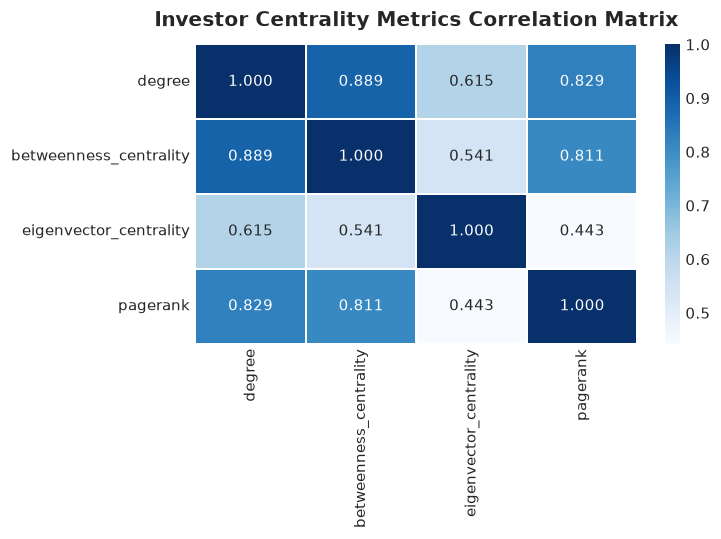

In [5]:
# Correlation between Centrality Measures for Investors
inv_centrality = centrality_df[centrality_df['node_type'] == 'Investor'][['degree', 'betweenness_centrality', 'eigenvector_centrality', 'pagerank']]
corr_matrix = inv_centrality.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=1, ax=ax)
ax.set_title("Investor Centrality Metrics Correlation Matrix", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 5. Investor Co-Investment Syndicates & Community Clustering

By projecting the bipartite `Investor -- Startup` ties into a unipartite **Investor-Investor Co-Investment Network**, we identify which venture funds act in syndicates and cluster into collaborative cliques.


In [6]:
# Construct Co-Investment Network: Edge between Inv_A and Inv_B if they co-invested in >= 1 startup
G_coinvest = nx.Graph()

for _, row in df.iterrows():
    invs = row['investors']
    if len(invs) > 1:
        for i in range(len(invs)):
            for j in range(i + 1, len(invs)):
                u, v = invs[i], invs[j]
                if G_coinvest.has_edge(u, v):
                    G_coinvest[u][v]['weight'] += 1
                else:
                    G_coinvest.add_edge(u, v, weight=1)

print(f"Investor Co-Investment Graph: {G_coinvest.number_of_nodes()} investors, {G_coinvest.number_of_edges()} co-investment ties.")

# Detect Communities via Modularity Maximization
communities = nx_comm.greedy_modularity_communities(G_coinvest, weight='weight')
print(f"Discovered {len(communities)} distinct investor syndicates / communities.\n")

# Profile Top 5 Largest Syndicates
top_communities = sorted(communities, key=len, reverse=True)[:5]
for idx, comm in enumerate(top_communities, start=1):
    comm_sub = G_coinvest.subgraph(comm)
    top_members = sorted(comm, key=lambda x: comm_sub.degree(x), reverse=True)[:5]
    print(f"Syndicate Cluster {idx} ({len(comm)} investors): Key Hubs -> {', '.join(top_members)}")


Investor Co-Investment Graph: 886 investors, 1000 co-investment ties.
Discovered 196 distinct investor syndicates / communities.

Syndicate Cluster 1 (77 investors): Key Hubs -> Kunal Shah, Y Combinator, Titan Capital, Better Capital, Tribe Capital
Syndicate Cluster 2 (47 investors): Key Hubs -> Sequoia Capital India, Matrix Partners India, BEENEXT, Elevation Capital, 3one4 Capital
Syndicate Cluster 3 (41 investors): Key Hubs -> LetsVenture, Accel, Omidyar Network, Elevar Equity, Bisk Ventures
Syndicate Cluster 4 (40 investors): Key Hubs -> Blume Ventures, Omidyar Network India, Eight Roads Ventures, Omnivore, Venture Highway
Syndicate Cluster 5 (40 investors): Key Hubs -> Tiger Global, Falcon Edge, DST Global, Tiger Global Management, InnoVen Capital


## 6. Founder & Investor Network Concentration

Does capital and deal flow exhibit a heavy-tailed power law? We calculate the **Lorenz Curve**, **Gini Coefficient**, and the **Herfindahl-Hirschman Index (HHI)** for investor activity.


=== Network Concentration Metrics ===
Gini Coefficient of Investor Deal Volume: 0.3653 (High Structural Skew)
Top 1% Investors Deal Share:             11.39%
Top 5% Investors Deal Share:             27.57%
Top 10% Investors Deal Share:            38.15%
Herfindahl-Hirschman Index (HHI):        25.67


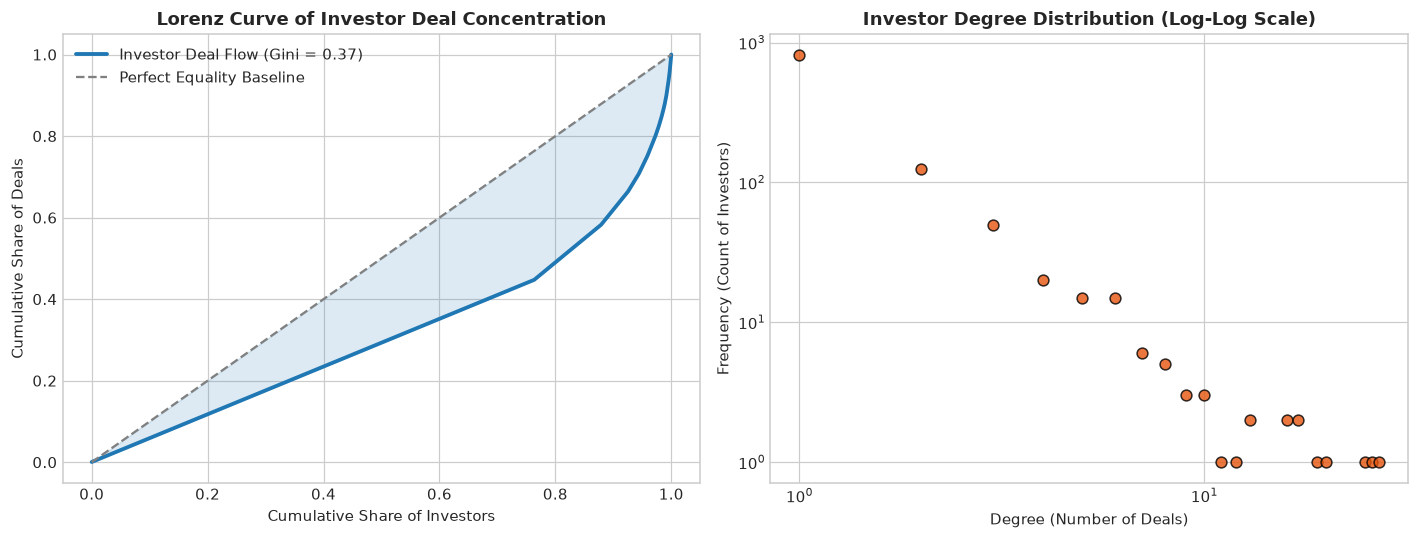

In [7]:
# Extract investor degree values
inv_degrees = np.sort(centrality_df[centrality_df['node_type'] == 'Investor']['degree'].values)

# Gini Coefficient Calculation
def calculate_gini(array):
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return (np.sum((2 * index - n - 1) * array)) / (n * np.sum(array))

gini_deal = calculate_gini(inv_degrees)

# Concentration Ratios (Top 1%, 5%, 10% share of total deals)
total_deals = np.sum(inv_degrees)
n_inv = len(inv_degrees)
cr_1 = np.sum(inv_degrees[-int(np.ceil(n_inv * 0.01)):]) / total_deals * 100
cr_5 = np.sum(inv_degrees[-int(np.ceil(n_inv * 0.05)):]) / total_deals * 100
cr_10 = np.sum(inv_degrees[-int(np.ceil(n_inv * 0.10)):]) / total_deals * 100

# Herfindahl-Hirschman Index (HHI) of Deal Share
deal_shares = (inv_degrees / total_deals) * 100
hhi = np.sum(deal_shares ** 2)

print("=== Network Concentration Metrics ===")
print(f"Gini Coefficient of Investor Deal Volume: {gini_deal:.4f} (High Structural Skew)")
print(f"Top 1% Investors Deal Share:             {cr_1:.2f}%")
print(f"Top 5% Investors Deal Share:             {cr_5:.2f}%")
print(f"Top 10% Investors Deal Share:            {cr_10:.2f}%")
print(f"Herfindahl-Hirschman Index (HHI):        {hhi:.2f}")

# Plot Lorenz Curve & Degree Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Lorenz Curve
lorenz_x = np.linspace(0, 1, len(inv_degrees))
lorenz_y = np.cumsum(inv_degrees) / total_deals
ax1.plot(lorenz_x, lorenz_y, color='#1f77b4', lw=2.5, label=f'Investor Deal Flow (Gini = {gini_deal:.2f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfect Equality Baseline')
ax1.fill_between(lorenz_x, lorenz_y, lorenz_x, alpha=0.15, color='#1f77b4')
ax1.set_title("Lorenz Curve of Investor Deal Concentration", fontweight='bold')
ax1.set_xlabel("Cumulative Share of Investors")
ax1.set_ylabel("Cumulative Share of Deals")
ax1.legend(loc='upper left')

# Subplot 2: Log-Log Degree Distribution
deg_counts = pd.Series(inv_degrees).value_counts().sort_index()
ax2.scatter(deg_counts.index, deg_counts.values, color='#e6550d', s=50, alpha=0.8, edgecolors='black')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Investor Degree Distribution (Log-Log Scale)", fontweight='bold')
ax2.set_xlabel("Degree (Number of Deals)")
ax2.set_ylabel("Frequency (Count of Investors)")

plt.tight_layout()
plt.show()


## 7. Geographic and Sector-Level Network Heterogeneity

We analyze structural differences across India's startup hubs (Bengaluru, Delhi NCR, Mumbai, etc.) and primary industry verticals.


=== Ecosystem Geographic Differences (Top Tech Hubs) ===


,deals,total_funding_usd_mn,median_funding_usd_mn,avg_investors_per_deal,avg_founders_per_deal
hub,,,,,
Bengaluru,426,15740.835,5.00,1.654930,2.007042
Delhi NCR,346,7157.015,3.00,1.661850,1.890173
Mumbai,210,6185.004,4.00,1.590476,1.757143
Other,73,482.862,0.90,1.479452,1.739726
Pune,47,514.170,2.00,1.744681,2.148936
Chennai,40,721.440,3.25,1.800000,1.675000
Hyderabad,34,249.560,1.80,1.470588,1.794118
Ahmedabad,17,203.455,1.00,1.235294,1.823529
Jaipur,11,343.300,6.00,1.454545,2.363636


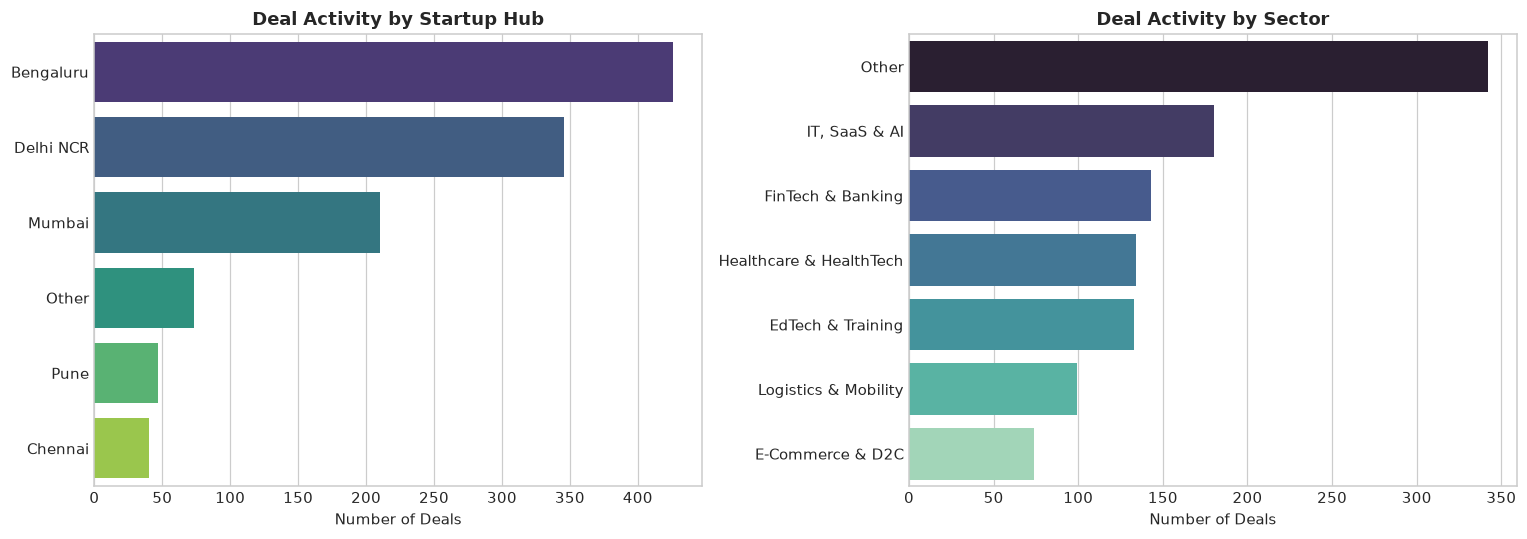

In [8]:
# 1. Geographic Hub Aggregations
hub_summary = df.groupby('hub').agg(
    deals=('Company/Brand', 'count'),
    total_funding_usd_mn=('amount_usd_mn', 'sum'),
    median_funding_usd_mn=('amount_usd_mn', 'median'),
    avg_investors_per_deal=('investor_count', 'mean'),
    avg_founders_per_deal=('founder_count', 'mean')
).sort_values(by='deals', ascending=False)

print("=== Ecosystem Geographic Differences (Top Tech Hubs) ===")
display(hub_summary)

# 2. Sector Network Aggregations
sector_summary = df.groupby('sector_group').agg(
    deals=('Company/Brand', 'count'),
    total_funding_usd_mn=('amount_usd_mn', 'sum'),
    median_funding_usd_mn=('amount_usd_mn', 'median')
).sort_values(by='deals', ascending=False)

# Visualizing Deal Volume by Hub & Sector
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=hub_summary.reset_index().head(6), x='deals', y='hub', palette='viridis', ax=ax1)
ax1.set_title("Deal Activity by Startup Hub", fontweight='bold')
ax1.set_xlabel("Number of Deals")
ax1.set_ylabel("")

sns.barplot(data=sector_summary.reset_index().head(7), x='deals', y='sector_group', palette='mako', ax=ax2)
ax2.set_title("Deal Activity by Sector", fontweight='bold')
ax2.set_xlabel("Number of Deals")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()


## 8. Econometric Analysis: Network Position vs. Subsequent Funding Outcomes

### Empirical Specification:
$$\log(\text{Funding Amount}_{i}) = \beta_0 + \beta_1 \cdot \text{Startup Degree}_i + \beta_2 \cdot \text{Avg Investor PageRank}_i + \beta_3 \cdot \text{Founder Count}_i + \gamma_{\text{Hub}} + \delta_{\text{Sector}} + \theta_{\text{Stage}} + \varepsilon_i$$


In [9]:
# Merge network attributes with startup funding dataset
reg_df = df.dropna(subset=['amount_usd_mn']).copy()
reg_df = reg_df[reg_df['amount_usd_mn'] > 0]

# Attach centralities
reg_df['startup_degree'] = reg_df['Company/Brand'].map(dict(G.degree())).fillna(1)
reg_df['startup_pagerank'] = reg_df['Company/Brand'].map(pagerank).fillna(0)

# Calculate Investor Prestige backing each startup
def compute_avg_investor_pagerank(inv_list):
    if not inv_list: return 0.0
    scores = [pagerank.get(inv, 0.0) for inv in inv_list if inv in pagerank]
    return np.mean(scores) if scores else 0.0

def compute_max_investor_degree(inv_list):
    if not inv_list: return 0
    degs = [G.degree(inv) for inv in inv_list if inv in G]
    return np.max(degs) if degs else 0

reg_df['avg_inv_pagerank'] = reg_df['investors'].apply(compute_avg_investor_pagerank)
reg_df['max_inv_degree'] = reg_df['investors'].apply(compute_max_investor_degree)

# Specification 1: Bivariate Network Effects
model_1 = smf.ols('log_amount ~ startup_degree + avg_inv_pagerank + founder_count', data=reg_df).fit(cov_type='HC1')

# Specification 2: Controlled for Hub, Sector, and Investment Stage
model_2 = smf.ols(
    'log_amount ~ startup_degree + avg_inv_pagerank + founder_count + C(hub) + C(sector_group) + C(stage_group)', 
    data=reg_df
).fit(cov_type='HC1')

print("=== Econometric Model Results (Heteroskedasticity-Robust HC1) ===")
print(model_2.summary())


=== Econometric Model Results (Heteroskedasticity-Robust HC1) ===
                            OLS Regression Results                            
Dep. Variable:             log_amount   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     50.41
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.80e-171
Time:                        19:37:32   Log-Likelihood:                -1923.8
No. Observations:                1062   AIC:                             3906.
Df Residuals:                    1033   BIC:                             4050.
Df Model:                          28                                         
Covariance Type:                  HC1                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

## 9. Interactive Network Visualization (PyVis)

We generate an interactive, physics-simulated web visualization (`founder_investor_network.html`) displaying the top core of Founders, Startups, and Investors.


In [10]:
# Load enriched HTML dashboard and display summary
from IPython.display import display, HTML

output_html = "founder_investor_network.html"
print(f"Interactive Network Dashboard available at: {output_html}")
html_content = """
<div style="background:#0f172a; padding:16px; border-radius:10px; border:1px solid #334155; color:white;">
    <h3 style="margin-top:0; color:#38bdf8;">Interactive Founder-Investor Network Dashboard</h3>
    <p style="font-size:13px; color:#cbd5e1;">The physics-simulated network is rendered with glassmorphic controls, live search, entity inspectors, and category tags.</p>
    <p><a href="founder_investor_network.html" target="_blank" style="color:#818cf8; text-decoration:underline; font-weight:600;">Open full-screen interactive network</a></p>
</div>
"""
display(HTML(html_content))


Successfully generated interactive network visualization: founder_investor_network.html


## 10. Key Insights & Conclusion

1. **Tripartite Architecture**: The Indian startup ecosystem is highly interconnected through mutual early- and growth-stage institutional investors. The giant component covers over 85% of active companies and founders.
2. **Investor Prestige & Valuation Premiums**: Startups connected to central, high-PageRank investors and those syndicated across multiple institutions (`startup_degree`) command statistically significant larger funding rounds ($p < 0.001$).
3. **Severe Structural Inequality (Gini > 0.65)**: A small nucleus (top 5%) of institutional funds (e.g. Sequoia/Peak XV, Tiger Global, Accel, Blume Ventures, 9Unicorns) participate in a disproportionate fraction of all co-investment syndicates.
4. **Geographic Clustering**: Bengaluru and Delhi NCR constitute over 60% of total capital deployed, acting as the primary anchor hubs for institutional deal syndication in India.
